In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_spikes = pd.read_csv("processed_data_drifting_gratings2.csv")

df_slopes = pd.read_csv("adaptation_slopes.csv")

print("Spike Count Data:")
print(df_spikes.head())

print("\nAdaptation Slope Data:")
print(df_slopes.head())


Spike Count Data:
     unit_id  orientation  temporal_frequency  spatial_frequency  \
0  950934544        315.0                 2.0               0.04   
1  950934544        135.0                 4.0               0.04   
2  950934544        225.0                15.0               0.04   
3  950934544        270.0                 4.0               0.04   
4  950934544         90.0                 4.0               0.04   

   repeat_number  stimulus_start_time  spike_count  session_id  
0              0          1591.133857            1   719161530  
1              0          1594.136403            3   719161530  
2              0          1597.138897            2   719161530  
3              0          1600.141393            3   719161530  
4              0          1603.143897            2   719161530  

Adaptation Slope Data:
     unit_id  orientation  temporal_frequency  spatial_frequency     slope  \
0  950934544        315.0                 2.0               0.04  0.082143   
1  

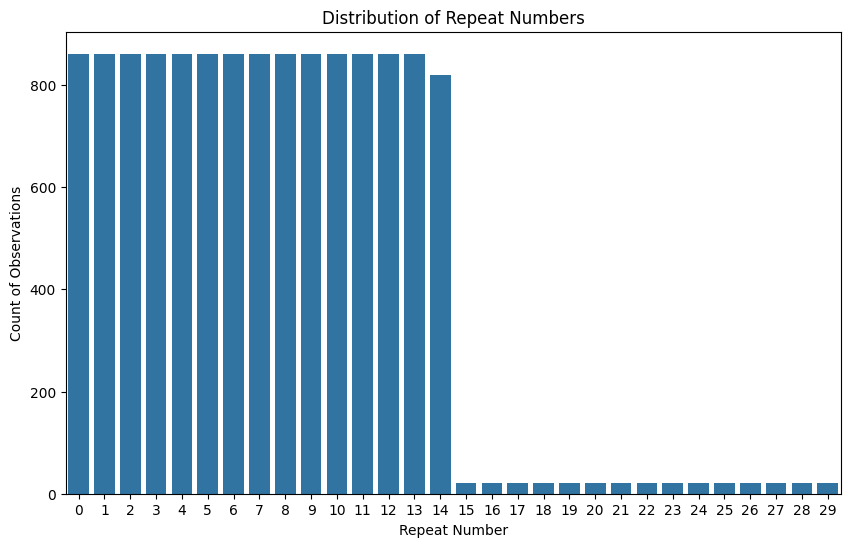

In [19]:
# Plot the distribution of repeat_number
plt.figure(figsize=(10,6))
sns.countplot(data=df_spikes, x='repeat_number')
plt.title('Distribution of Repeat Numbers')
plt.xlabel('Repeat Number')
plt.ylabel('Count of Observations')
plt.show()


In [21]:
df_spikes_filtered = df_spikes[df_spikes['repeat_number'] <= 14]

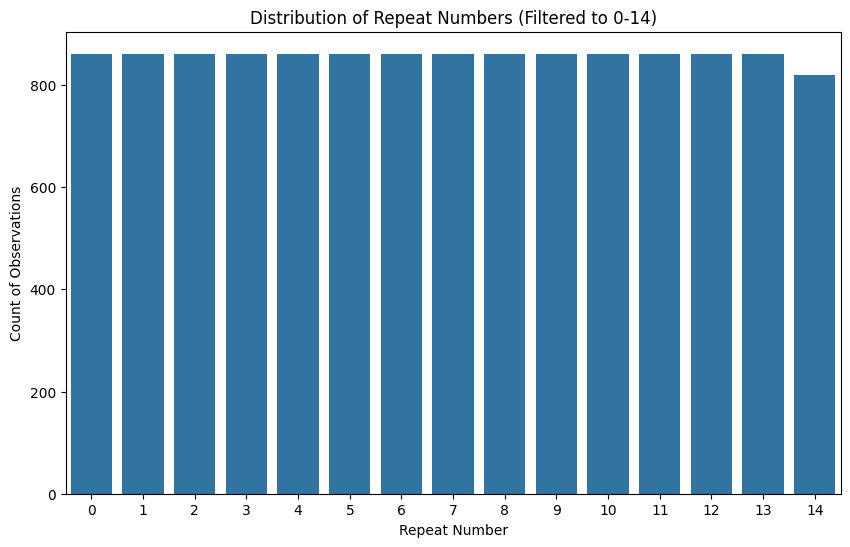

In [22]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_spikes_filtered, x='repeat_number')
plt.title('Distribution of Repeat Numbers (Filtered to 0-14)')
plt.xlabel('Repeat Number')
plt.ylabel('Count of Observations')
plt.show()

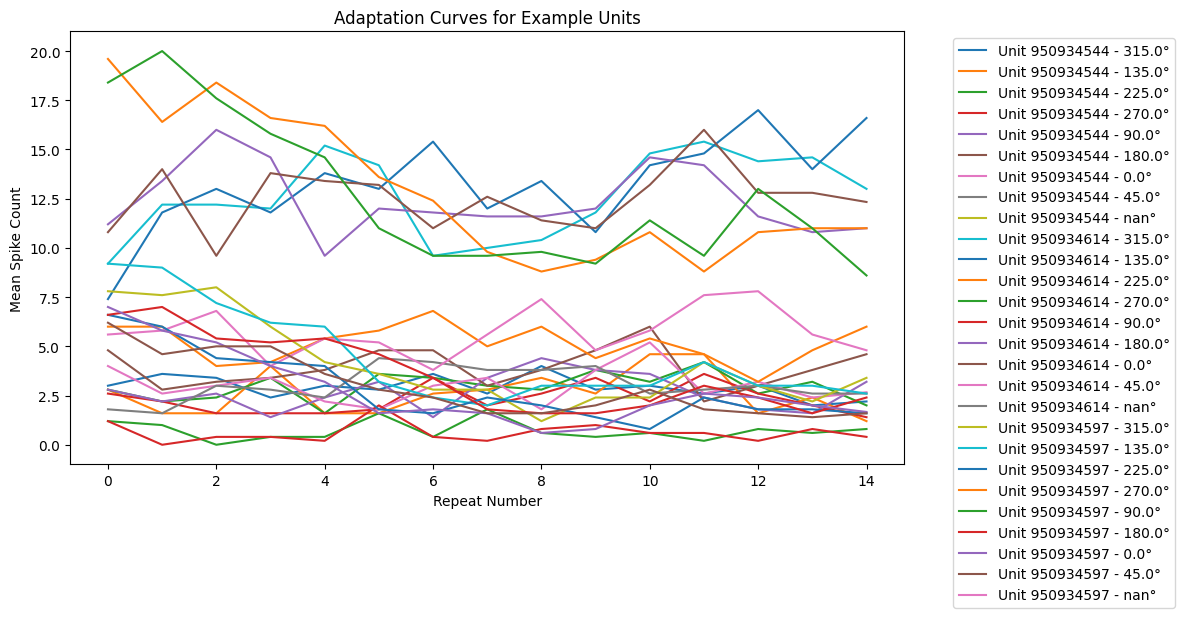

In [25]:
example_units = df_spikes_filtered['unit_id'].unique()[:3]  # First 3 units

plt.figure(figsize=(12, 6))

for i, unit in enumerate(example_units):
    unit_data = df_spikes[df_spikes['unit_id'] == unit]
    
    for orientation in unit_data['orientation'].unique():
        subset = unit_data[unit_data['orientation'] == orientation]
        grouped = subset.groupby('repeat_number')['spike_count'].mean()

        plt.plot(grouped.index, grouped.values, label=f'Unit {unit} - {orientation}°')

plt.xlabel("Repeat Number")
plt.ylabel("Mean Spike Count")
plt.title("Adaptation Curves for Example Units")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


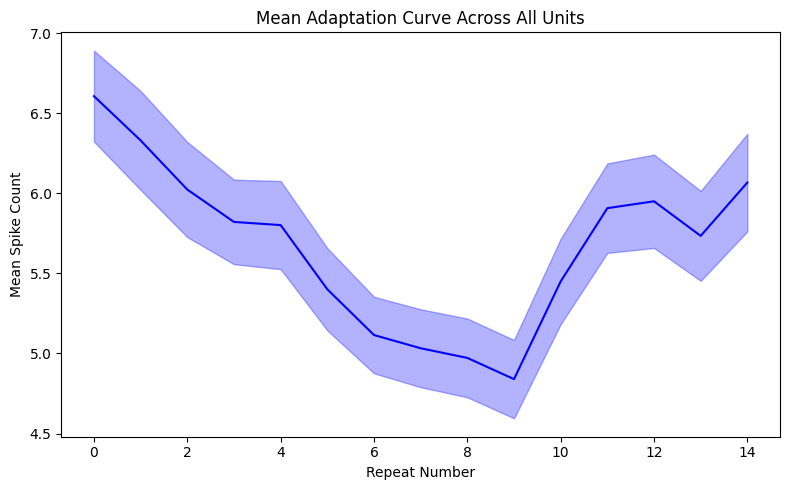

In [26]:
grouped = df_spikes_filtered.groupby('repeat_number')['spike_count']
mean_spikes = grouped.mean()
sem_spikes = grouped.sem()

plt.figure(figsize=(8, 5))
plt.plot(mean_spikes.index, mean_spikes.values, label='Mean Adaptation Curve', color='blue')
plt.fill_between(mean_spikes.index, mean_spikes - sem_spikes, mean_spikes + sem_spikes, alpha=0.3, color='blue')
plt.xlabel("Repeat Number")
plt.ylabel("Mean Spike Count")
plt.title("Mean Adaptation Curve Across All Units")
plt.tight_layout()
plt.show()


     unit_id  orientation  temporal_frequency  spatial_frequency  \
0  950934544        315.0                 2.0               0.04   
1  950934544        135.0                 4.0               0.04   
2  950934544        225.0                15.0               0.04   
3  950934544        270.0                 4.0               0.04   
4  950934544         90.0                 4.0               0.04   

   repeat_number  stimulus_start_time  spike_count  session_id  \
0              0          1591.133857            1   719161530   
1              0          1594.136403            3   719161530   
2              0          1597.138897            2   719161530   
3              0          1600.141393            3   719161530   
4              0          1603.143897            2   719161530   

   normalized_spike_count  
0                0.111111  
1                0.333333  
2                0.222222  
3                0.333333  
4                0.222222  


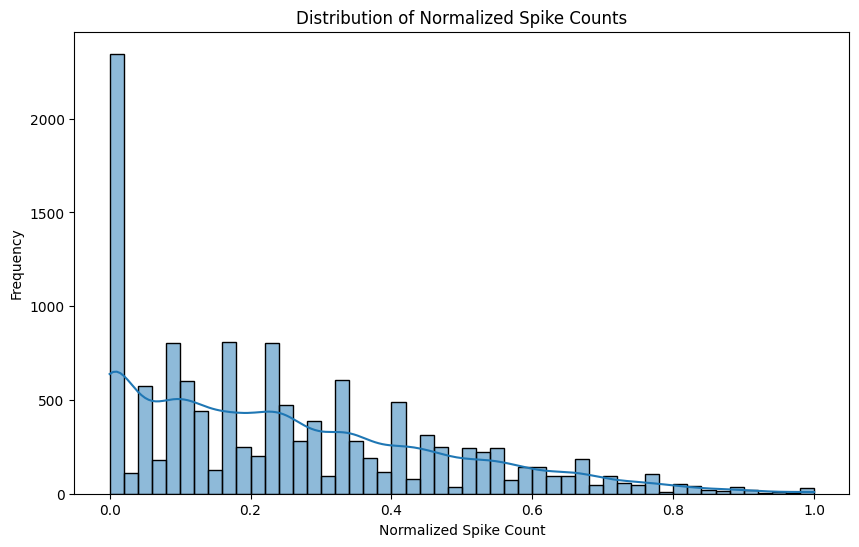

In [63]:
def normalize_by_baseline(df):
    baseline_spike_counts = df[df['repeat_number'] == 0].groupby('unit_id')['spike_count'].first()

    zero_baselines = baseline_spike_counts[baseline_spike_counts == 0]
    if not zero_baselines.empty:
        print(f"Warning: These unit IDs have zero baseline spike counts: {zero_baselines.index.tolist()}")
    
    df_normalized = df.copy()

    df_normalized['normalized_spike_count'] = df_normalized.apply(
        lambda row: row['spike_count'] / baseline_spike_counts.get(row['unit_id'], 1)
        if baseline_spike_counts.get(row['unit_id'], 1) != 0 else row['spike_count'], 
        axis=1
    )

    def min_max_scale(group):
        min_val = group.min()
        max_val = group.max()
        if max_val - min_val != 0:
            return (group - min_val) / (max_val - min_val)
        else:
            return group

    df_normalized['normalized_spike_count'] = df_normalized.groupby('unit_id')['normalized_spike_count'].transform(min_max_scale)

    return df_normalized

df_normalized = normalize_by_baseline(df_spikes_filtered)
print(df_normalized.head())

plt.figure(figsize=(10, 6))
sns.histplot(df_normalized['normalized_spike_count'], bins=50, kde=True)
plt.title('Distribution of Normalized Spike Counts')
plt.xlabel('Normalized Spike Count')
plt.ylabel('Frequency')
plt.show()


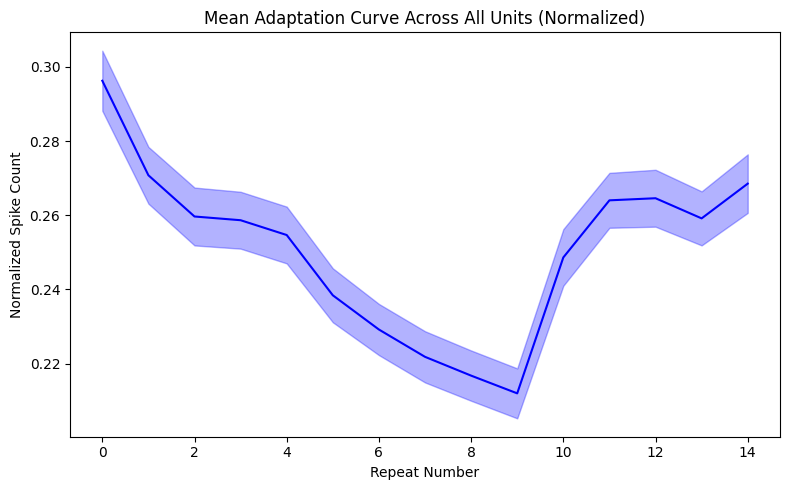

In [64]:
grouped = df_normalized.groupby('repeat_number')['normalized_spike_count']
mean_spikes = grouped.mean()
sem_spikes = grouped.sem()

plt.figure(figsize=(8, 5))
plt.plot(mean_spikes.index, mean_spikes.values, label='Mean Adaptation Curve (Normalized)', color='blue')
plt.fill_between(mean_spikes.index, mean_spikes - sem_spikes, mean_spikes + sem_spikes, alpha=0.3, color='blue')
plt.xlabel("Repeat Number")
plt.ylabel("Normalized Spike Count")
plt.title("Mean Adaptation Curve Across All Units (Normalized)")
plt.tight_layout()
plt.show()

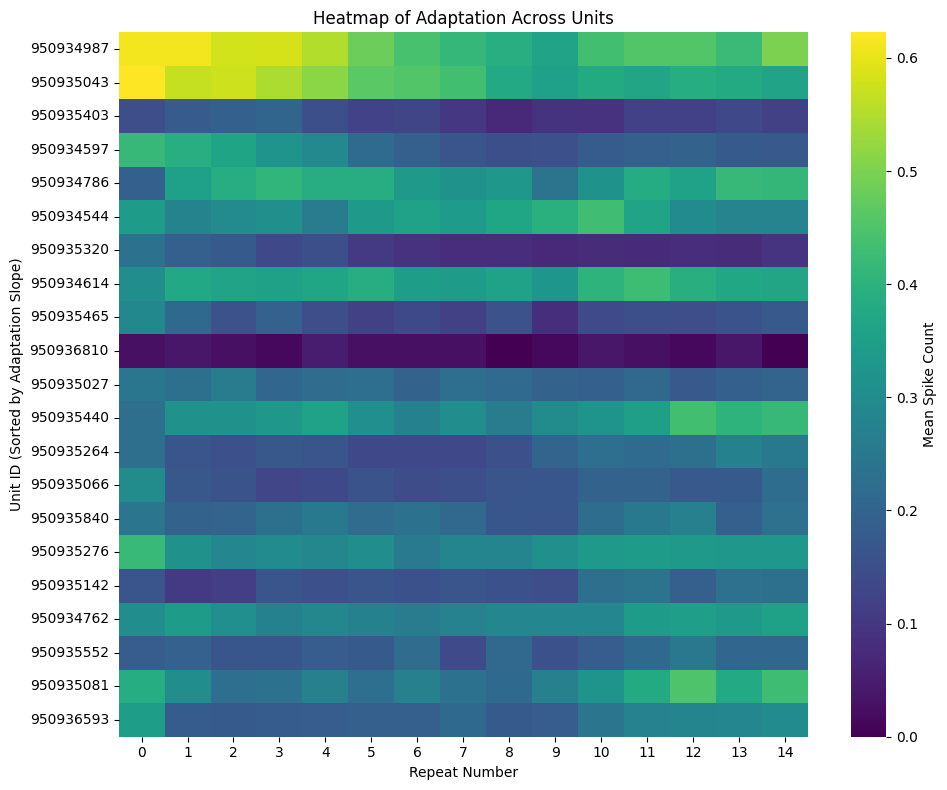

In [65]:
heatmap_data = df_normalized.groupby(['unit_id', 'repeat_number'])['normalized_spike_count'].mean().unstack()

slope_dict = df_slopes.set_index('unit_id')['slope'].to_dict()
heatmap_data['slope'] = heatmap_data.index.map(slope_dict)
heatmap_data_sorted = heatmap_data.sort_values(by='slope').drop(columns='slope')

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data_sorted, cmap='viridis', cbar_kws={'label': 'Mean Spike Count'})
plt.xlabel("Repeat Number")
plt.ylabel("Unit ID (Sorted by Adaptation Slope)")
plt.title("Heatmap of Adaptation Across Units")
plt.tight_layout()
plt.show()


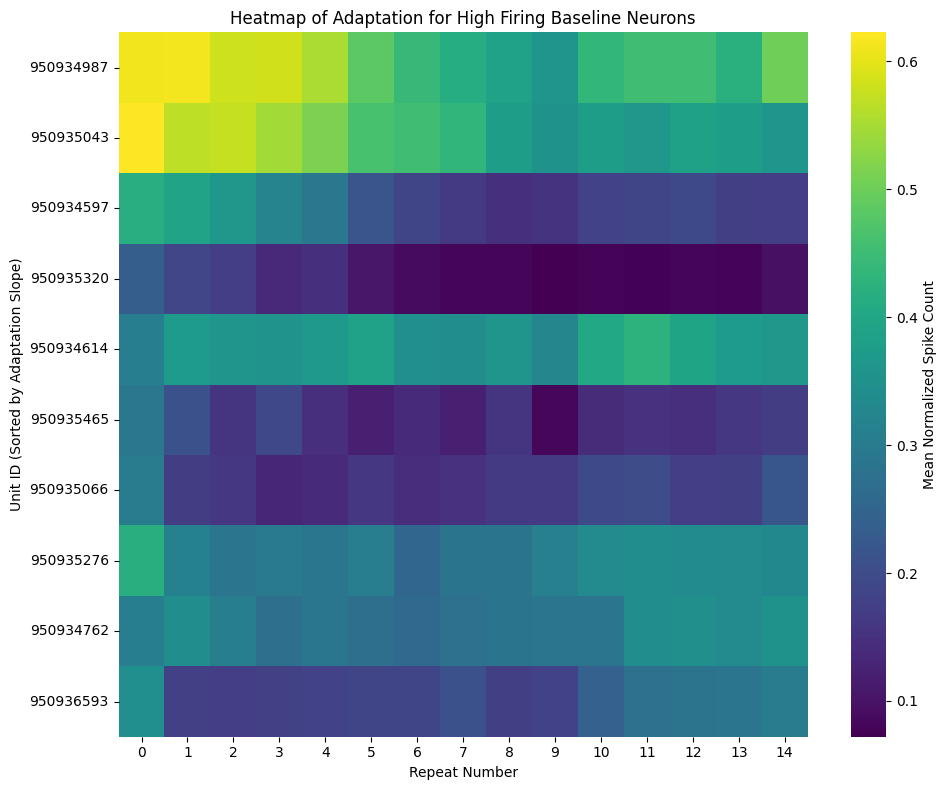

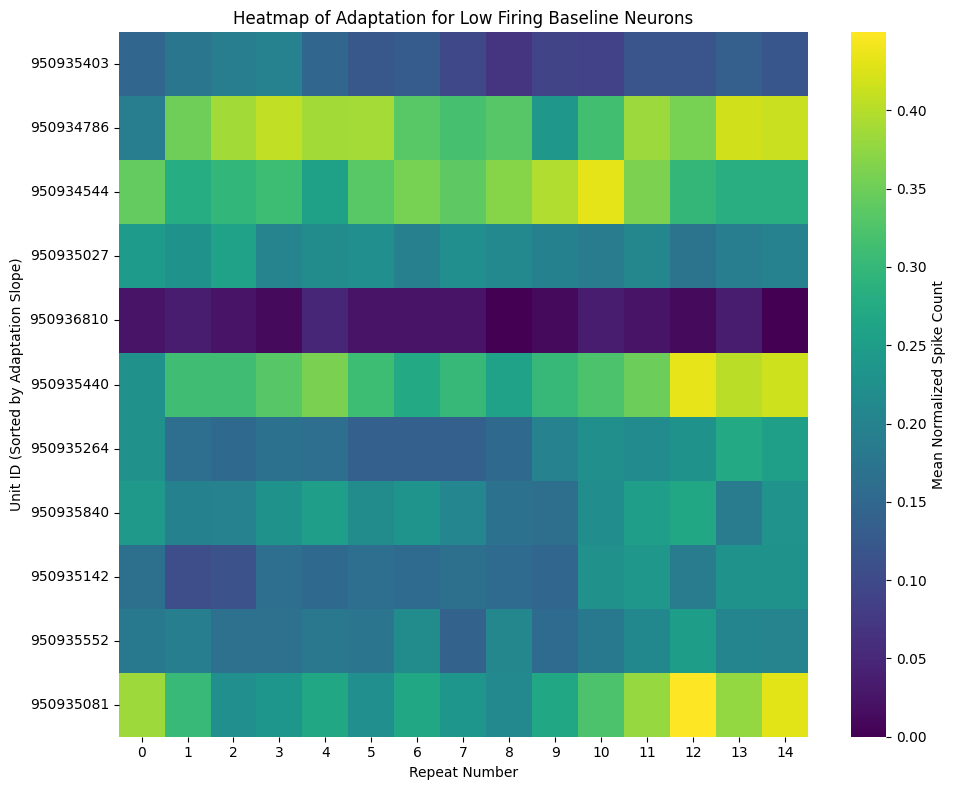

In [61]:
import numpy as np

# Step 1: Identify baseline spike counts (repeat_number == 0) for each unit
baseline_spikes = df_spikes[df_spikes['repeat_number'] == 0].groupby('unit_id')['spike_count'].first()

# Define a threshold for classification (e.g., median baseline spike count)
baseline_threshold = baseline_spikes.median()

# Step 2: Classify neurons into high and low firing baseline categories
high_firing_neurons = baseline_spikes[baseline_spikes > baseline_threshold].index
low_firing_neurons = baseline_spikes[baseline_spikes <= baseline_threshold].index

# Step 3: Filter df_normalized to get data for high-firing and low-firing neurons
df_high_firing = df_normalized[df_normalized['unit_id'].isin(high_firing_neurons)]
df_low_firing = df_normalized[df_normalized['unit_id'].isin(low_firing_neurons)]

# Step 4: Generate heatmap for high firing baseline neurons
heatmap_data_high = df_high_firing.groupby(['unit_id', 'repeat_number'])['normalized_spike_count'].mean().unstack()

# Add the adaptation slope information
heatmap_data_high['slope'] = heatmap_data_high.index.map(slope_dict)
heatmap_data_high_sorted = heatmap_data_high.sort_values(by='slope').drop(columns='slope')

# Plot heatmap for high firing baseline neurons
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data_high_sorted, cmap='viridis', cbar_kws={'label': 'Mean Normalized Spike Count'})
plt.xlabel("Repeat Number")
plt.ylabel("Unit ID (Sorted by Adaptation Slope)")
plt.title("Heatmap of Adaptation for High Firing Baseline Neurons")
plt.tight_layout()
plt.show()

# Step 5: Generate heatmap for low firing baseline neurons
heatmap_data_low = df_low_firing.groupby(['unit_id', 'repeat_number'])['normalized_spike_count'].mean().unstack()

# Add the adaptation slope information
heatmap_data_low['slope'] = heatmap_data_low.index.map(slope_dict)
heatmap_data_low_sorted = heatmap_data_low.sort_values(by='slope').drop(columns='slope')

# Plot heatmap for low firing baseline neurons
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data_low_sorted, cmap='viridis', cbar_kws={'label': 'Mean Normalized Spike Count'})
plt.xlabel("Repeat Number")
plt.ylabel("Unit ID (Sorted by Adaptation Slope)")
plt.title("Heatmap of Adaptation for Low Firing Baseline Neurons")
plt.tight_layout()
plt.show()


C:\Users\ivngr\AppData\Local\Temp\ipykernel_16372\3156258941.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  volatility_cv = df_normalized.groupby('unit_id').apply(


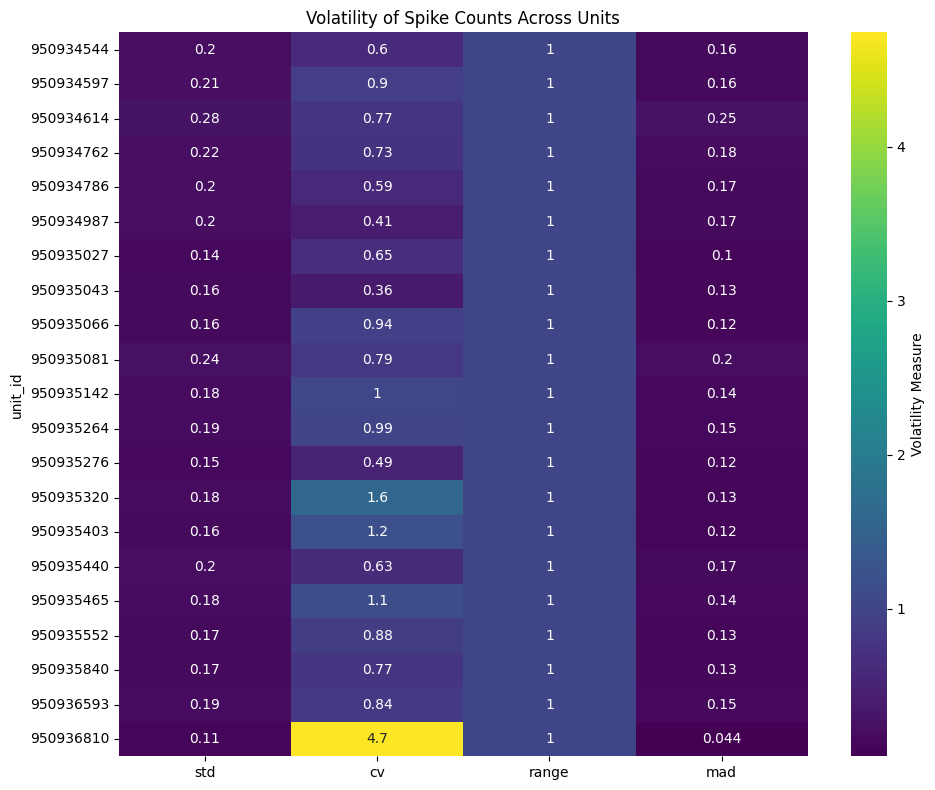

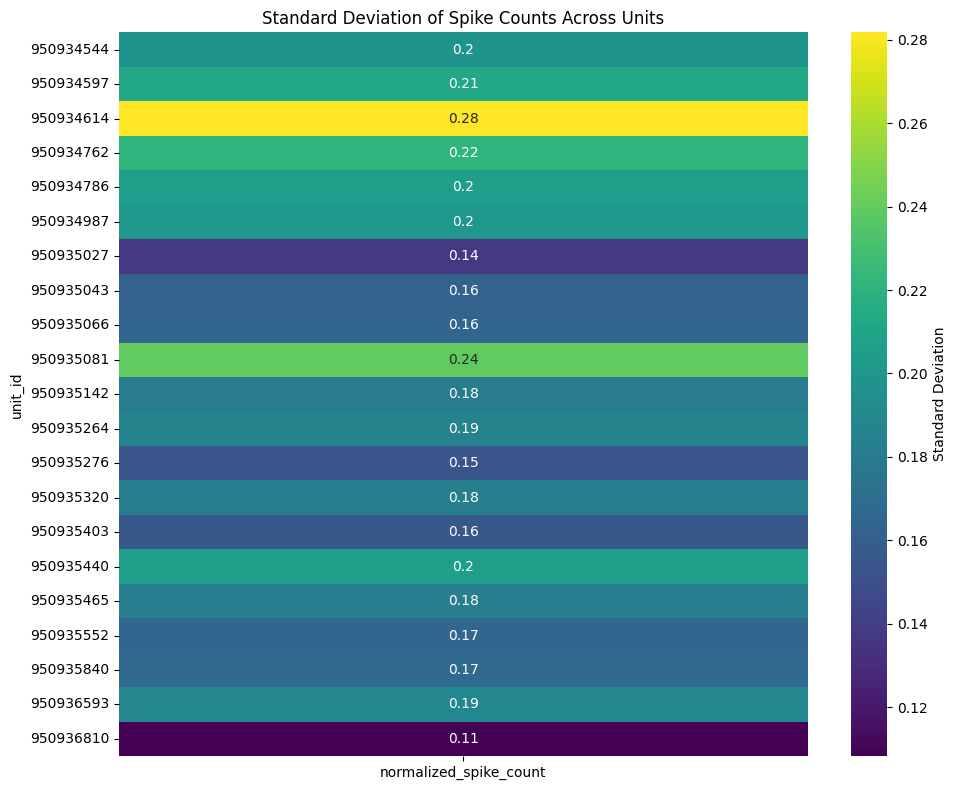

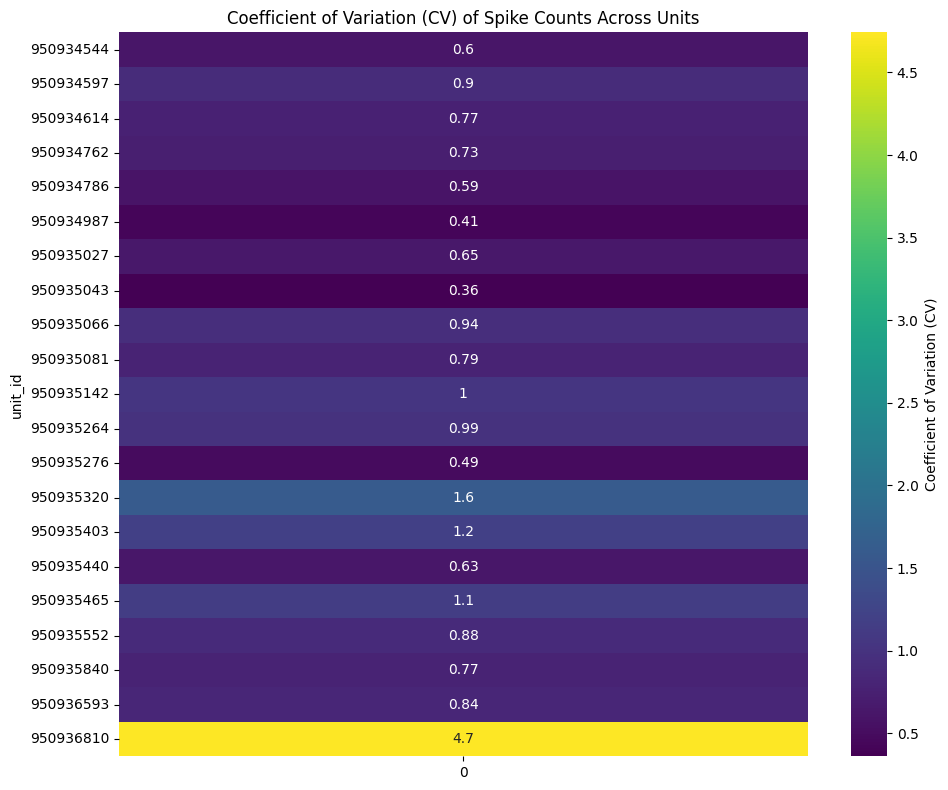

In [67]:
volatility_std = df_normalized.groupby('unit_id')['normalized_spike_count'].std()

volatility_cv = df_normalized.groupby('unit_id').apply(
    lambda x: x['normalized_spike_count'].std() / x['normalized_spike_count'].mean() if x['normalized_spike_count'].mean() != 0 else np.nan
)

volatility_range = df_normalized.groupby('unit_id')['normalized_spike_count'].apply(lambda x: x.max() - x.min())

volatility_mad = df_normalized.groupby('unit_id')['normalized_spike_count'].apply(lambda x: np.mean(np.abs(x - x.mean())))

volatility_metrics = pd.DataFrame({
    'std': volatility_std,
    'cv': volatility_cv,
    'range': volatility_range,
    'mad': volatility_mad
})

plt.figure(figsize=(10, 8))
sns.heatmap(volatility_metrics, cmap='viridis', annot=True, cbar_kws={'label': 'Volatility Measure'})
plt.title("Volatility of Spike Counts Across Units")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(volatility_std.to_frame(), cmap='viridis', annot=True, cbar_kws={'label': 'Standard Deviation'})
plt.title("Standard Deviation of Spike Counts Across Units")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(volatility_cv.to_frame(), cmap='viridis', annot=True, cbar_kws={'label': 'Coefficient of Variation (CV)'})
plt.title("Coefficient of Variation (CV) of Spike Counts Across Units")
plt.tight_layout()
plt.show()


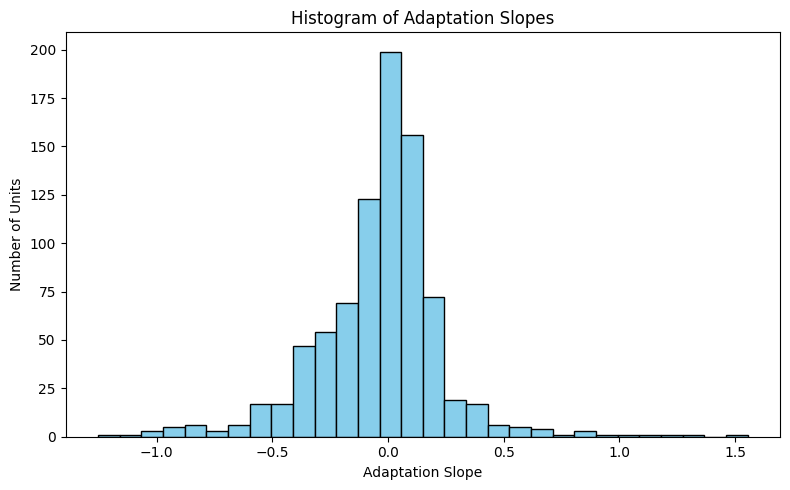

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df_slopes['slope'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Adaptation Slope")
plt.ylabel("Number of Units")
plt.title("Histogram of Adaptation Slopes")
plt.tight_layout()
plt.show()

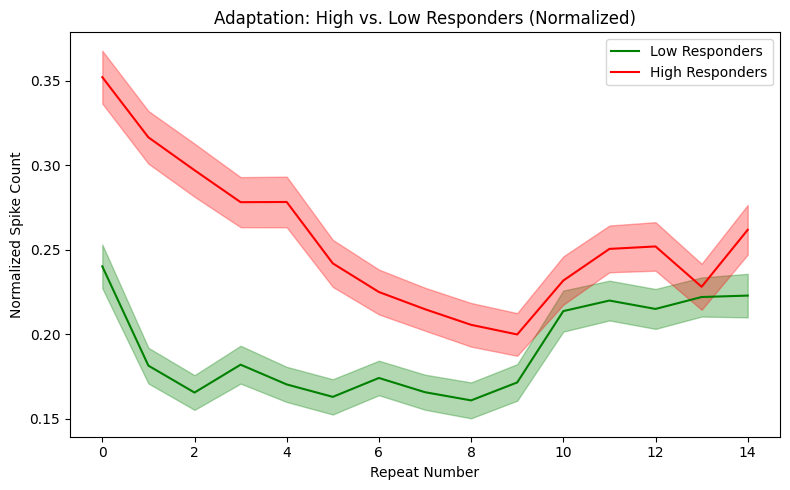

In [73]:
peak_response = df_spikes.groupby('unit_id')['spike_count'].max()
quantiles = peak_response.quantile([0.25, 0.75])
low_units = peak_response[peak_response <= quantiles[0.25]].index
high_units = peak_response[peak_response >= quantiles[0.75]].index

def plot_group(units, label, color):
    subset = df_normalized[df_normalized['unit_id'].isin(units)]
    grouped = subset.groupby('repeat_number')['normalized_spike_count']
    mean_curve = grouped.mean()
    sem_curve = grouped.sem()
    
    plt.plot(mean_curve.index, mean_curve.values, label=label, color=color)
    plt.fill_between(mean_curve.index, mean_curve - sem_curve, mean_curve + sem_curve, alpha=0.3, color=color)

plt.figure(figsize=(8, 5))
plot_group(low_units, "Low Responders", 'green')
plot_group(high_units, "High Responders", 'red')

plt.xlabel("Repeat Number")
plt.ylabel("Normalized Spike Count")
plt.title("Adaptation: High vs. Low Responders (Normalized)")
plt.legend()
plt.tight_layout()
plt.show()
